# Stationwise evaluation

Use the reusable functions from `compile_results_functions.py` to evaluate predictions overall and per station without rebuilding the long notebook workflow.

In [18]:
from pathlib import Path
import os
import sys
from obspy import read
import matplotlib.pyplot as plt

import pandas as pd

# Make the helper module importable when running the notebook from VS Code.
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from compile_results_functions import (
    build_waveform_index,
    compute_metrics,
    format_metrics_report,
    load_prediction_csvs,
    merge_predictions_and_truth,
    plot_pred_row,
    prepare_long_predictions,
)


In [3]:
# Core configuration
waveform_type = "earthquakes"
model_type = "eqcct"

base_path = "../results/csv"
data_dir = f"../data/waveforms_{waveform_type}_nonoise"
gt_path = Path(base_path) / "ground_truth"

subdir = f"{model_type}_{waveform_type}_th0_1"
gt_fname = f"{subdir}.csv"

# Keep the notebook read-only by default.
# Flip this to True only if you explicitly want to write derived CSV files.
save_outputs = False
csv_output_path = os.path.join(base_path, "combined") if save_outputs else None
csv_output_name = f"{subdir}_full.csv" if save_outputs else None

time_threshold = "10s"

# Control how the stationwise table is sorted.
# Set sort_columns to None to keep the original order.
sort_columns = ["f1_score", "precision", "recall"]
sort_ascending = [False, False, False]


In [4]:
def evaluate_station(group_df, truth_df, *, p_threshold=0.1, time_threshold="10s"):
    """Evaluate one station group and return a metrics dictionary."""

    if group_df.empty:
        return None

    row0 = group_df.iloc[0]
    station_truth = truth_df[
        (truth_df["network"] == row0.network) & (truth_df["station"] == row0.station)
    ]

    if station_truth.empty:
        return None

    station_pred_long = prepare_long_predictions(group_df, p_threshold=p_threshold)
    station_preds_on_picks, station_picks_on_preds = merge_predictions_and_truth(
        station_pred_long,
        station_truth,
        time_threshold=time_threshold,
    )
    metrics = compute_metrics(station_preds_on_picks, station_picks_on_preds)

    metrics["network"] = row0.network
    metrics["station"] = row0.station
    metrics["num_rows"] = len(group_df)
    metrics["num_true_picks"] = len(station_truth)
    metrics["num_predictions"] = len(station_pred_long)
    return metrics

In [5]:
# Load and normalize the prediction CSVs.
df_predictions = load_prediction_csvs(
    base_path,
    subdir,
    csv_output_path=csv_output_path,
    csv_output_name=csv_output_name,
)

p_threshold = 0.1

# Build the waveform index if you want to plot individual stations later.
waveform_idx = build_waveform_index(data_dir)

# Load the existing ground-truth CSV from results/csv/ground_truth.
gt_file = gt_path / gt_fname
if not gt_file.exists():
    raise FileNotFoundError(f"Missing ground-truth CSV: {gt_file.resolve()}")

df_true = pd.read_csv(gt_file)
if not df_true.empty:
    df_true["true_arrival_time"] = pd.to_datetime(df_true["true_arrival_time"], errors="coerce")
    df_true = df_true.dropna(subset=["true_arrival_time", "network", "station", "phase"])
    df_true["network"] = df_true["network"].astype(str).str.strip().str.upper()
    df_true["station"] = df_true["station"].astype(str).str.strip().str.upper()
    df_true["phase"] = df_true["phase"].astype(str).str.strip().str.upper()

# Evaluate the full dataset.
df_pred_long = prepare_long_predictions(df_predictions, p_threshold=p_threshold)
preds_on_picks, picks_on_preds = merge_predictions_and_truth(
    df_pred_long,
    df_true,
    time_threshold=time_threshold,
)
metrics = compute_metrics(preds_on_picks, picks_on_preds)
metrics_string = format_metrics_report(metrics, subdir)
print(metrics_string)

# Stationwise metrics.
station_metrics = []
for _, group_df in df_predictions.groupby(["network", "station"]):
    station_result = evaluate_station(
        group_df,
        df_true,
        p_threshold=p_threshold,
        time_threshold=time_threshold,
    )
    if station_result is not None:
        station_metrics.append(station_result)

station_metrics_df = pd.DataFrame(station_metrics)
if not station_metrics_df.empty and sort_columns is not None:
    station_metrics_df = station_metrics_df.sort_values(sort_columns, ascending=sort_ascending)
    display(station_metrics_df)
elif not station_metrics_df.empty:
    display(station_metrics_df)

# Keep the results in memory unless you explicitly enable save_outputs.
if save_outputs and not station_metrics_df.empty:
    station_metrics_path = os.path.join(base_path.replace("csv", "metrics"), f"{subdir}_stationwise.csv")
    os.makedirs(os.path.dirname(station_metrics_path), exist_ok=True)
    station_metrics_df.to_csv(station_metrics_path, index=False)
    print(f"Saved stationwise metrics to {station_metrics_path}")


Evaluated predictions from: eqcct_earthquakes_th0_1

=========== Overall metrics ===========
True Positives:        2884
False Positives:       611
False Negatives:       1127
Total predictions:     3495
Total picks:           4011
Recall:                0.7190226876090751
Precision:             0.8251788268955651
F1 Score:              0.7684519051425527

=========== Metrics for p-picks ===========
True Positives:        1458
False Positives:       578
False Negatives:       120
Total predictions:     2036
Total picks:           1578
Recall:                0.9239543726235742
Precision:             0.7161100196463654
F1 Score:              0.8068622025456558

=========== Metrics for s-picks ===========
True Positives:        1426
False Positives:       33
False Negatives:       1007
Total predictions:     1459
Total picks:           2433
Recall:                0.5861076859843815
Precision:             0.9773817683344757
F1 Score:              0.7327852004110997



,TP,FP,FN,num_preds,num_picks,recall,precision,f1_score,TP_p,TP_s,...,recall_s,precision_p,precision_s,f1_score_p,f1_score_s,network,station,num_rows,num_true_picks,num_predictions
2,93,8,13,101,106,0.877358,0.920792,0.898551,48,45,...,0.775862,0.857143,1.000000,0.923077,0.873786,FN,MSF,56,106,101
21,83,8,12,91,95,0.873684,0.912088,0.892473,41,42,...,0.792453,0.854167,0.976744,0.911111,0.875000,HE,KU6,49,95,91
3,97,11,15,108,112,0.866071,0.898148,0.881818,47,50,...,0.793651,0.810345,1.000000,0.878505,0.884956,FN,OLKF,59,112,108
18,52,2,12,54,64,0.812500,0.962963,0.881356,27,25,...,0.694444,0.900000,1.041667,0.931034,0.833333,HE,KEV,30,64,54
38,94,14,17,108,111,0.846847,0.870370,0.858447,48,46,...,0.741935,0.813559,0.938776,0.888889,0.828829,HE,VAF,59,111,108
39,90,3,28,93,118,0.762712,0.967742,0.853081,45,45,...,0.692308,0.918367,1.022727,0.882353,0.825688,HE,VJF,49,118,93
6,145,19,33,164,178,0.814607,0.884146,0.847953,71,74,...,0.718447,0.797753,0.986667,0.865854,0.831461,FN,RANF,94,178,164
19,90,20,15,110,105,0.857143,0.818182,0.837209,41,49,...,0.765625,0.694915,0.960784,0.820000,0.852174,HE,KIF,59,105,110
12,141,21,35,162,176,0.801136,0.870370,0.834320,71,70,...,0.693069,0.788889,0.972222,0.860606,0.809249,HE,HEF,92,176,162
7,153,23,40,176,193,0.792746,0.869318,0.829268,77,76,...,0.678571,0.777778,0.987013,0.855556,0.804233,FN,RNF,101,193,176


Inspecting station: HE.JOF (F1=0.522, precision=0.600, recall=0.462, predictions=10)
False-positive predictions for HE.JOF: 4


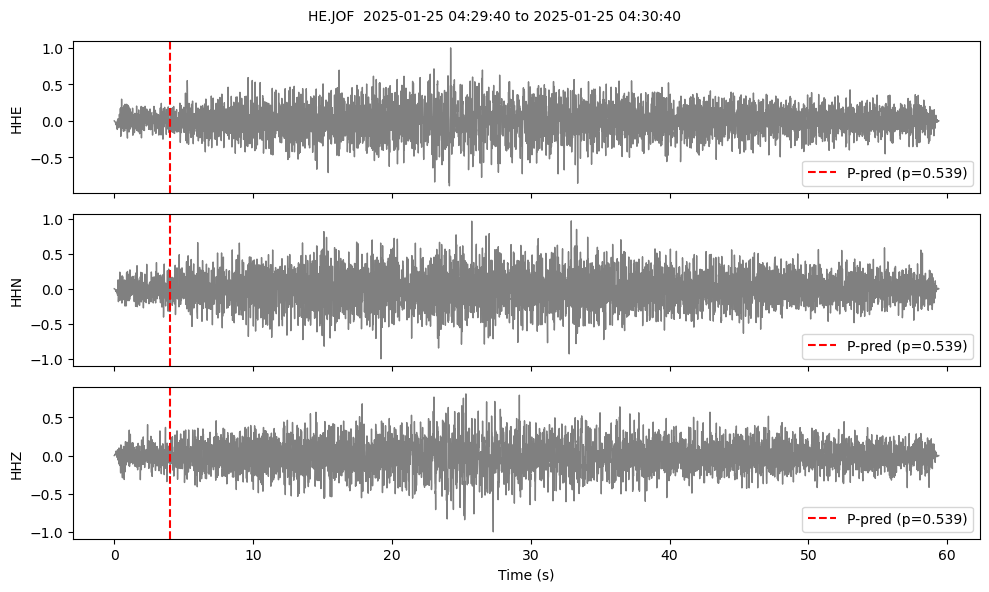

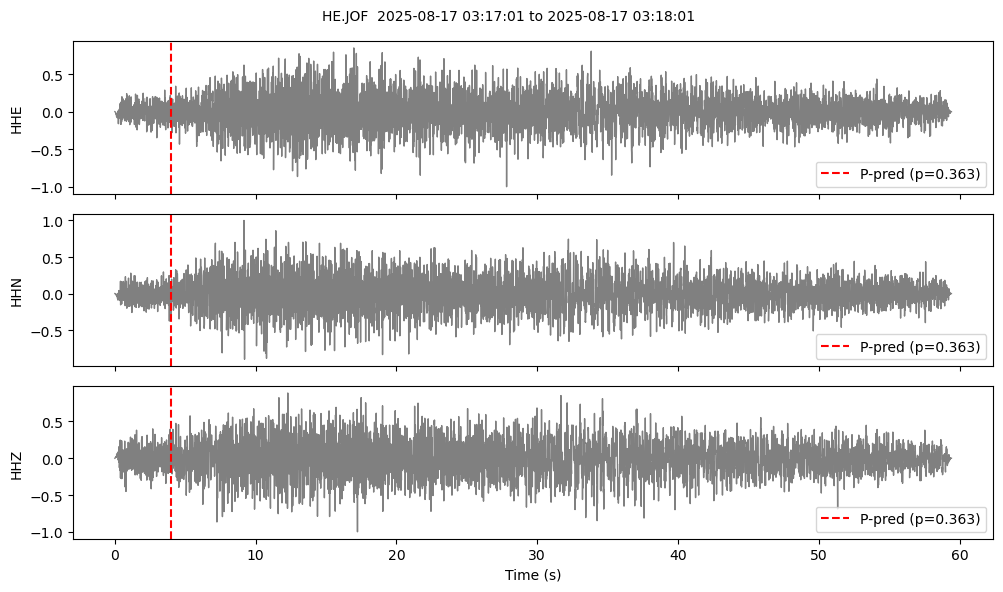

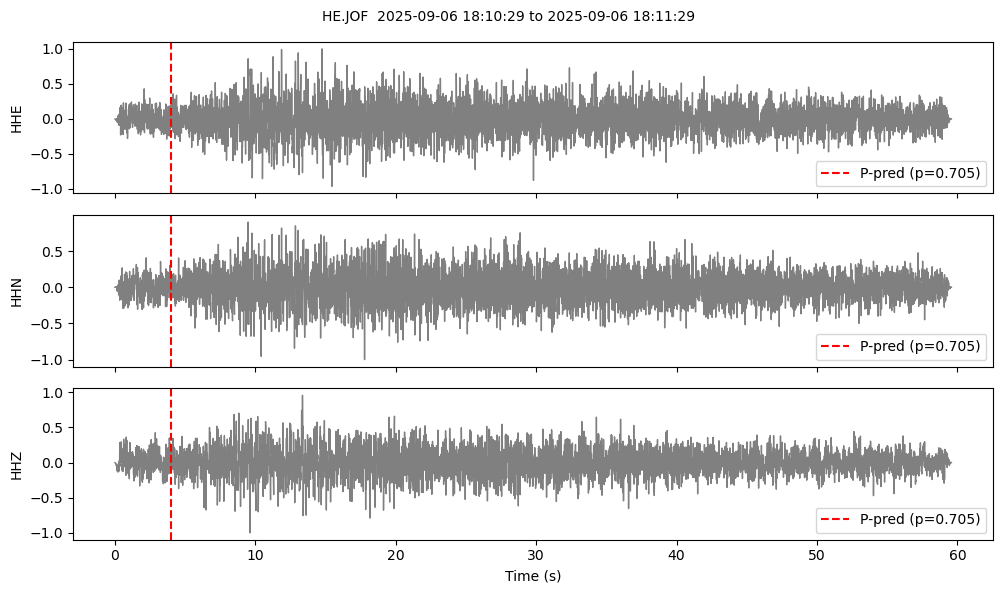

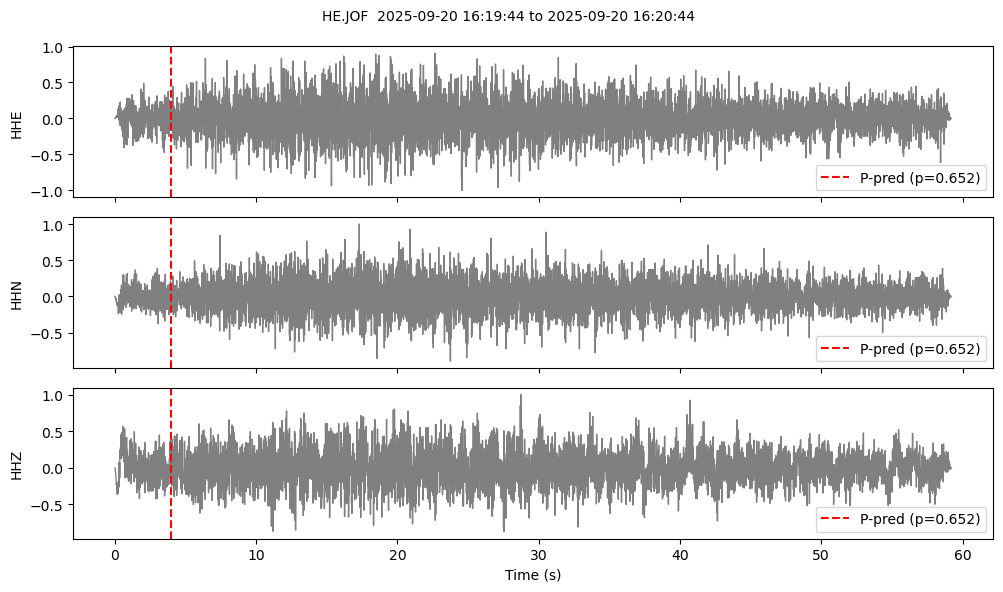

In [8]:
# Plot missed detections or false alarms for a user-selected station.
station_to_inspect = "HE.JOF"  # format: "NET.STA"
inspect_mode = "false_positive"  # "false_positive" or "false_negative"
max_plots = 20

if station_metrics_df.empty:
    print("No stationwise metrics available yet.")
else:
    station_text = str(station_to_inspect).strip().upper()
    if "." not in station_text:
        raise ValueError(
            "station_to_inspect must be in 'NET.STA' format, for example 'HE.RSUO'."
        )

    selected_network, selected_station = station_text.split(".", 1)
    mode = str(inspect_mode).strip().lower()
    if mode not in {"false_positive", "false_negative"}:
        raise ValueError("inspect_mode must be either 'false_positive' or 'false_negative'.")

    station_candidates = station_metrics_df[
        (station_metrics_df["network"].astype(str).str.upper() == selected_network)
        & (station_metrics_df["station"].astype(str).str.upper() == selected_station)
    ]

    if station_candidates.empty:
        raise ValueError(
            f"Station '{station_to_inspect}' not found in station_metrics_df. "
            "Check station_metrics_df[['network', 'station']] for available values."
        )

    chosen_row = station_candidates.sort_values(
        ["f1_score", "precision", "recall"],
        ascending=[True, True, True],
    ).iloc[0]

    print(
        f"Inspecting station: {selected_network}.{selected_station} "
        f"(F1={chosen_row['f1_score']:.3f}, "
        f"precision={chosen_row['precision']:.3f}, "
        f"recall={chosen_row['recall']:.3f}, "
        f"predictions={int(chosen_row['num_predictions'])})"
    )

    station_predictions = df_predictions[
        (df_predictions["network"] == selected_network)
        & (df_predictions["station"] == selected_station)
    ].copy()
    if not station_predictions.empty:
        station_predictions["start_dt"] = pd.to_datetime(station_predictions["start_dt"], errors="coerce")
        station_predictions["end_dt"] = pd.to_datetime(station_predictions["end_dt"], errors="coerce")

    station_pred_long = prepare_long_predictions(
        station_predictions,
        p_threshold=p_threshold,
    )

    station_truth = df_true[
        (df_true["network"] == selected_network)
        & (df_true["station"] == selected_station)
    ]

    station_preds_on_picks, station_picks_on_preds = merge_predictions_and_truth(
        station_pred_long,
        station_truth,
        time_threshold=time_threshold,
    )

    if mode == "false_positive":
        selected_rows = station_preds_on_picks[
            station_preds_on_picks["true_arrival_time"].isna()
        ].copy()
        selected_rows = selected_rows.sort_values("pred_arrival_time")
        print(
            f"False-positive predictions for {selected_network}.{selected_station}: "
            f"{len(selected_rows)}"
        )
    else:
        selected_rows = station_picks_on_preds[
            station_picks_on_preds["probability"].isna()
        ].copy()
        selected_rows = selected_rows.sort_values("true_arrival_time")
        print(
            f"False-negative picks for {selected_network}.{selected_station}: "
            f"{len(selected_rows)}"
        )

    if selected_rows.empty:
        print(f"No {mode.replace('_', ' ')} samples found for this station.")
    else:
        num_plots = min(max_plots, len(selected_rows))
        for _, row in selected_rows.head(num_plots).iterrows():
            if mode == "false_positive":
                start_dt = row.start_dt
                end_dt = row.end_dt
                phase = row.phase
                arrival_time = row.pred_arrival_time
                probability = row.probability
            else:
                phase = row.phase
                arrival_time = row.true_arrival_time
                probability = 1.0  # Ensure marker is plotted for missed true picks.
                matching_windows = station_predictions[
                    (station_predictions["start_dt"] <= arrival_time)
                    & (station_predictions["end_dt"] >= arrival_time)
                ]
                if matching_windows.empty:
                    print(
                        f"Skipped {row.network}.{row.station} {arrival_time} "
                        "because no prediction window covered that true pick."
                    )
                    continue
                window_row = matching_windows.iloc[0]
                start_dt = window_row.start_dt
                end_dt = window_row.end_dt

            row_dict = {
                "network": row.network,
                "station": row.station,
                "start_dt": start_dt,
                "end_dt": end_dt,
                "p_arrival_time": pd.NaT,
                "s_arrival_time": pd.NaT,
                "p_probability": None,
                "s_probability": None,
            }
            if phase == "P":
                row_dict["p_arrival_time"] = arrival_time
                row_dict["p_probability"] = probability
            elif phase == "S":
                row_dict["s_arrival_time"] = arrival_time
                row_dict["s_probability"] = probability

            plotted = plot_pred_row(pd.Series(row_dict), waveform_idx, p_tr=p_threshold)
            if not plotted:
                print(
                    f"Skipped {row.network}.{row.station} {arrival_time} "
                    "because the waveform could not be loaded."
                )


In [7]:
def generate_and_save_stationwise_metrics(model_type, waveform_type, base_path, gt_path, 
                                          p_threshold=0.1, time_threshold="10s",
                                          sort_columns=None, sort_ascending=None):
    """
    Generate stationwise metrics for a model/waveform combination and save to CSV.
    
    Returns:
        tuple: (station_metrics_df, output_path) or (None, None) if failed
    """
    
    subdir = f"{model_type}_{waveform_type}_th0_1"
    gt_fname = f"{subdir}.csv"
    
    print(f"Processing {model_type.upper()} - {waveform_type.upper()}...", end=" ")
    
    # Load predictions
    try:
        df_predictions = load_prediction_csvs(str(base_path), subdir)
    except Exception as e:
        print(f"✗ Error loading predictions: {e}")
        return None, None
    
    if df_predictions.empty:
        print("✗ No predictions found")
        return None, None
    
    # Load ground truth
    gt_file = Path(gt_path) / gt_fname
    if not gt_file.exists():
        print(f"✗ Missing ground truth CSV")
        return None, None
    
    try:
        df_true = pd.read_csv(gt_file)
        if not df_true.empty:
            df_true["true_arrival_time"] = pd.to_datetime(df_true["true_arrival_time"], errors="coerce")
            df_true = df_true.dropna(subset=["true_arrival_time", "network", "station", "phase"])
            df_true["network"] = df_true["network"].astype(str).str.strip().str.upper()
            df_true["station"] = df_true["station"].astype(str).str.strip().str.upper()
            df_true["phase"] = df_true["phase"].astype(str).str.strip().str.upper()
    except Exception as e:
        print(f"✗ Error loading ground truth: {e}")
        return None, None
    
    if df_true.empty:
        print("✗ No ground truth data")
        return None, None
    
    # Compute stationwise metrics
    try:
        station_metrics = []
        for _, group_df in df_predictions.groupby(["network", "station"]):
            station_result = evaluate_station(
                group_df,
                df_true,
                p_threshold=p_threshold,
                time_threshold=time_threshold,
            )
            if station_result is not None:
                station_metrics.append(station_result)
        
        if not station_metrics:
            print("✗ No stationwise metrics computed")
            return None, None
        
        station_metrics_df = pd.DataFrame(station_metrics)
        
        # Sort if specified
        if sort_columns is not None and sort_ascending is not None:
            station_metrics_df = station_metrics_df.sort_values(sort_columns, ascending=sort_ascending)
        
        # Save to CSV
        metrics_dir = Path(str(base_path).replace("csv", "metrics"))
        metrics_dir.mkdir(parents=True, exist_ok=True)
        
        output_path = metrics_dir / f"{subdir}_stationwise.csv"
        station_metrics_df.to_csv(output_path, index=False)
        
        print(f"✓ Saved to {output_path.name} ({len(station_metrics_df)} stations)")
        return station_metrics_df, str(output_path)
        
    except Exception as e:
        print(f"✗ Error computing metrics: {e}")
        return None, None


# Configuration
base_path = Path("../results/csv")
gt_path = base_path / "ground_truth"
p_threshold = 0.1
time_threshold = "10s"

# Sort by F1 score, precision, and recall (descending)
sort_columns = ["f1_score", "precision", "recall"]
sort_ascending = [False, False, False]

# Define all model and waveform type combinations
models = ["eqcct", "eqt"]
waveform_types = ["earthquakes", "explosions", "noise"]

print("=" * 70)
print("Generating Stationwise Metrics CSV Files")
print("=" * 70)
print()

# Store results for summary
results = {}

for model in models:
    for waveform in waveform_types:
        df, output_path = generate_and_save_stationwise_metrics(
            model, waveform, base_path, gt_path,
            p_threshold=p_threshold,
            time_threshold=time_threshold,
            sort_columns=sort_columns,
            sort_ascending=sort_ascending
        )
        
        if df is not None:
            key = f"{model}_{waveform}"
            results[key] = {
                "df": df,
                "path": output_path,
                "num_stations": len(df),
            }

print()
print("=" * 70)
print("Summary")
print("=" * 70)

if results:
    for key, info in results.items():
        print(f"✓ {key:30s}: {info['num_stations']:3d} stations")
    print()
    print(f"All CSV files saved to: {gt_path.parent / 'metrics'}")
else:
    print("⚠ No metrics files were generated. Check your paths and data.")

Generating Stationwise Metrics CSV Files

Processing EQCCT - EARTHQUAKES... 

✓ Saved to eqcct_earthquakes_th0_1_stationwise.csv (43 stations)
Processing EQCCT - EXPLOSIONS... 

/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


✓ Saved to eqcct_explosions_th0_1_stationwise.csv (49 stations)
Processing EQCCT - NOISE... 

/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


✗ Missing ground truth CSV
Processing EQT - EARTHQUAKES... ✓ Saved to eqt_earthquakes_th0_1_stationwise.csv (43 stations)
Processing EQT - EXPLOSIONS... 

/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


✓ Saved to eqt_explosions_th0_1_stationwise.csv (49 stations)
Processing EQT - NOISE... 

/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


✗ Missing ground truth CSV

Summary
✓ eqcct_earthquakes             :  43 stations
✓ eqcct_explosions              :  49 stations
✓ eqt_earthquakes               :  43 stations
✓ eqt_explosions                :  49 stations

All CSV files saved to: ../results/csv/metrics


In [20]:
# Analyze false positives in the noise dataset

def analyze_noise_false_positives(
    model="eqcct",
    base_path=Path("../results/csv"),
    p_threshold=0.1,
):
    """
    Analyze false positives by station for noise dataset.
    
    Since there is no ground truth for pure noise, all predictions are false positives.
    
    Returns DataFrame with columns: network, station, num_fp, num_windows, fp_rate
    """
    
    subdir = f"{model}_noise_th0_1"
    print(f"Loading predictions for {subdir}...")
    
    try:
        df_pred = load_prediction_csvs(str(base_path), subdir)
    except Exception as e:
        print("Error loading predictions:", e)
        return None, None
    
    if df_pred.empty:
        print("No predictions found for", subdir)
        return None, None
    
    # Prepare long-form predictions (all are false positives for noise)
    df_pred_long = prepare_long_predictions(df_pred, p_threshold=p_threshold)
    
    if df_pred_long.empty:
        print("No predictions above threshold")
        return None, None
    
    # Group by station and count FPs
    station_fp_summary = []
    for (network, station), group in df_pred_long.groupby(["network", "station"]):
        num_fp = len(group)
        # Count unique time windows as a proxy for "number of noise samples"
        num_windows = group[["start_dt", "end_dt"]].drop_duplicates().shape[0]
        fp_rate = num_fp / num_windows if num_windows > 0 else 0
        
        station_fp_summary.append({
            "network": network,
            "station": station,
            "num_fp": num_fp,
            "num_windows": num_windows,
            "fp_rate": fp_rate,
        })
    
    summary_df = pd.DataFrame(station_fp_summary)
    summary_df = summary_df.sort_values("num_fp", ascending=False)
    
    return summary_df, df_pred_long


def plot_station_false_positives(
    model,
    station_to_plot,
    df_pred_long,
    base_path,
    p_threshold=0.1,
    max_plots=10,
):
    """
    Plot false positives for a specific station in the noise dataset.
    
    Parameters:
    - model: 'eqcct' or 'eqt'
    - station_to_plot: tuple (network, station) or "NET.STA" string
    - df_pred_long: DataFrame of long-form predictions from analyze_noise_false_positives
    - base_path: path to results
    - p_threshold: probability threshold
    - max_plots: max number of FPs to plot for this station
    """
    
    # Parse station format
    if isinstance(station_to_plot, str):
        if "." not in station_to_plot:
            raise ValueError("station_to_plot must be 'NET.STA' format")
        network, station = station_to_plot.upper().split(".", 1)
    else:
        network, station = station_to_plot
    
    # Filter to this station
    station_fps = df_pred_long[
        (df_pred_long["network"].astype(str).str.upper() == network) &
        (df_pred_long["station"].astype(str).str.upper() == station)
    ].copy()
    
    if station_fps.empty:
        print(f"No false positives found for {network}.{station}")
        return
    
    print(f"\nPlotting up to {max_plots} false positives for {network}.{station} ({len(station_fps)} total)")
    
    # Build waveform index
    data_dir = "../data/waveforms_noise_only"
    try:
        waveform_idx = build_waveform_index(data_dir)
    except Exception as e:
        print(f"Error building waveform index: {e}")
        waveform_idx = None
    
    if waveform_idx is None:
        print("Cannot plot without waveform index")
        return
    
    # Plot up to max_plots
    plotted = 0
    for _, row in station_fps.iterrows():
        if plotted >= max_plots:
            break
        try:
            from obspy import Stream, UTCDateTime, read
            
            # Load station window
            start_str = UTCDateTime(row.start_dt).strftime("%Y%m%dT%H%M%SZ")
            end_str = UTCDateTime(row.end_dt).strftime("%Y%m%dT%H%M%SZ")
            key = (network, station, start_str, end_str)
            
            if key not in waveform_idx:
                print(f"  Skipped {network}.{station} {row.start_dt}: waveform not indexed")
                continue
            
            st = Stream()
            for path in waveform_idx[key]:
                st += read(path)
            
            if len(st) == 0:
                print(f"  Skipped {network}.{station} {row.start_dt}: no waveform data")
                continue
            
            # Trim and merge
            start = UTCDateTime(row.start_dt)
            end = UTCDateTime(row.end_dt)
            st.merge(method=1, fill_value="interpolate")
            st.trim(start, end)
            
            # Resample if needed
            for tr in st:
                if tr.stats.sampling_rate > 100:
                    tr.resample(100)
            
            # Create plot
            fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
            fig.suptitle(f"{network}.{station}  {row.start_dt} to {row.end_dt}", fontsize=10)
            
            channels = [tr.stats.channel for tr in st]
            
            for j, ch in enumerate(channels):
                tr_sel = st.select(channel=ch)
                if len(tr_sel) == 0:
                    continue
                
                # Process waveform
                tr = tr_sel[0].copy()
                tr.detrend("linear")
                tr.detrend("demean")
                tr.filter("bandpass", freqmin=1, freqmax=45, corners=2, zerophase=True)
                tr.taper(max_percentage=0.01, type="cosine", max_length=2)
                tr.normalize()
                
                # Plot
                t = tr.times()
                axes[j].plot(t, tr.data, color="grey", linewidth=1)
                
                # Mark predicted arrivals
                if pd.notna(row.pred_arrival_time):
                    time_pred = UTCDateTime(row.pred_arrival_time) - tr.stats.starttime
                    phase_label = row.get("phase", "?")
                    prob = row.get("probability", 0)
                    color = "b" if phase_label == "P" else "r"
                    axes[j].axvline(time_pred, color=color, linewidth=1.5, linestyle="dashed",
                                   label=f"{phase_label}-pred (p={prob:.3f})")
                
                axes[j].set_ylabel(ch)
                axes[j].legend(loc="lower right")
            
            axes[-1].set_xlabel("Time (s)")
            plt.tight_layout()
            plt.show()
            plotted += 1
            
        except Exception as e:
            print(f"  Plot failed for {network}.{station} {row.start_dt}: {e}")
    
    print(f"Plotted {plotted} false positives")


# Analyze both models
print("=" * 70)
print("False Positive Analysis for Noise Dataset")
print("=" * 70)
print()

base_path = Path("../results/csv")
p_threshold = 0.1

results_noise_fp = {}

for model in ["eqcct", "eqt"]:
    print(f"\n{model.upper()}:")
    summary, df_long = analyze_noise_false_positives(model, base_path, p_threshold)
    if summary is not None:
        results_noise_fp[model] = {"summary": summary, "long": df_long}
        print(f"Summary of false positives by station:")
        display(summary)
    else:
        print("Could not analyze FPs")

False Positive Analysis for Noise Dataset


EQCCT:
Loading predictions for eqcct_noise_th0_1...


/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


Summary of false positives by station:


,network,station,num_fp,num_windows,fp_rate
23,HE,KEV,16,16,1.000000
25,HE,KORF,12,9,1.333333
24,HE,KIF,12,7,1.714286
17,HE,HEF,10,9,1.111111
2,FN,RAJF,9,9,1.000000
26,HE,KPF,8,7,1.142857
33,HE,OBF0,6,6,1.000000
1,FN,KMNF,6,5,1.200000
35,HE,OUF,5,3,1.666667
34,HE,OBF3,5,4,1.250000



EQT:
Loading predictions for eqt_noise_th0_1...


/home/akuburas/projects/eqcct/eqcctpro/notebooks/compile_results_functions.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


Summary of false positives by station:


,network,station,num_fp,num_windows,fp_rate
17,HE,KIF,18,9,2.000000
27,HE,OBF8,15,6,2.500000
19,HE,KORF,15,5,3.000000
12,HE,HEF,12,7,1.714286
0,FN,KMNF,9,5,1.800000
22,HE,KU6,7,5,1.400000
16,HE,KEV,6,4,1.500000
3,HE,FIA1,5,2,2.500000
18,HE,KJNF,5,1,5.000000
21,HE,KU2,4,2,2.000000



Plotting up to 5 false positives for HE.KORF (15 total)


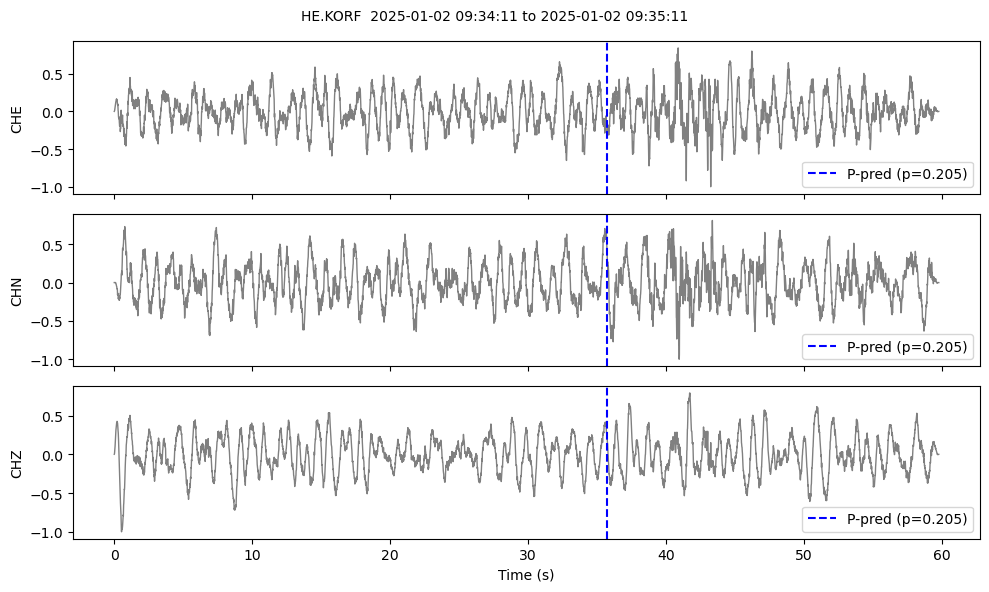

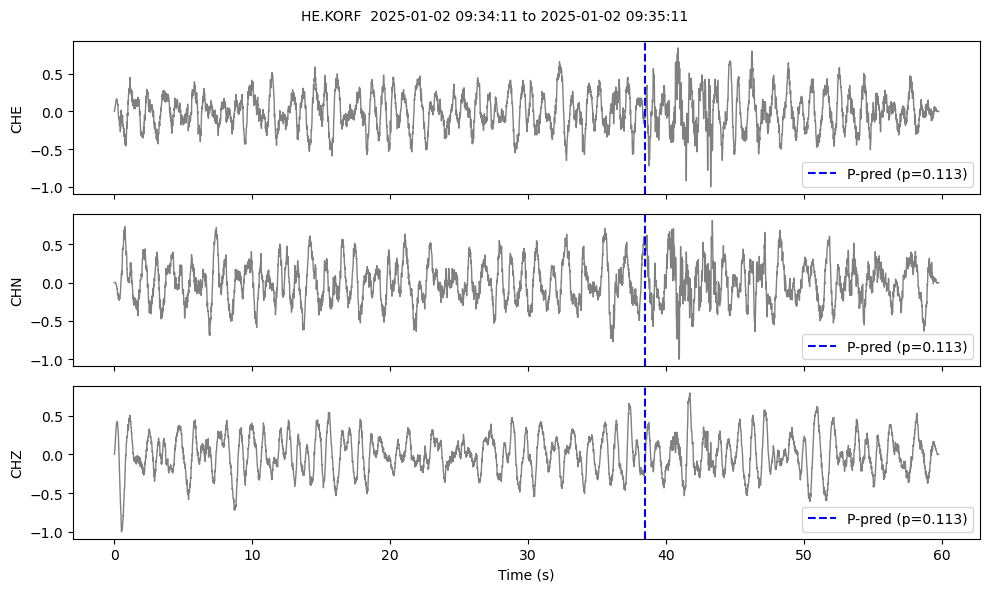

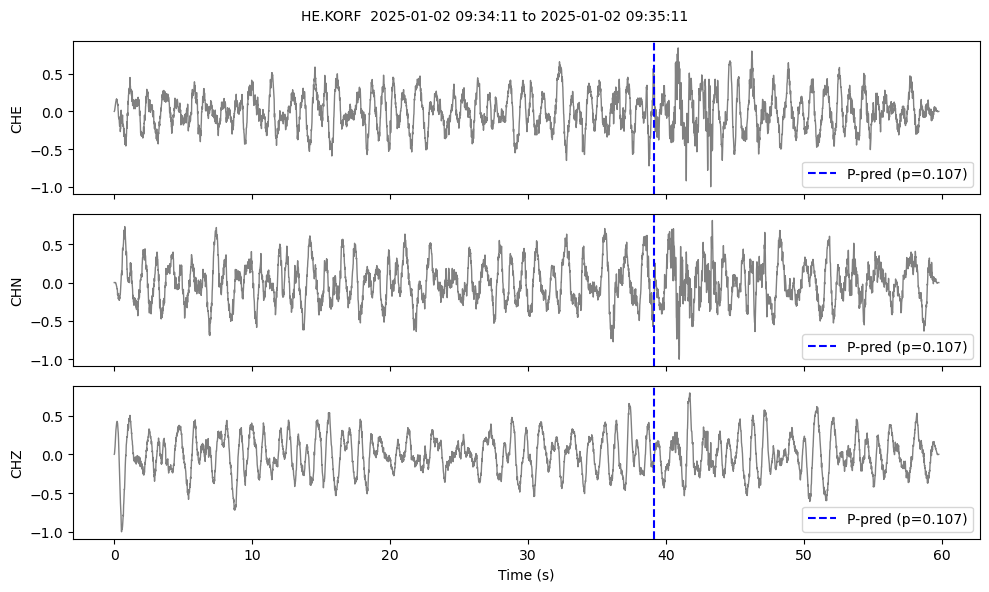

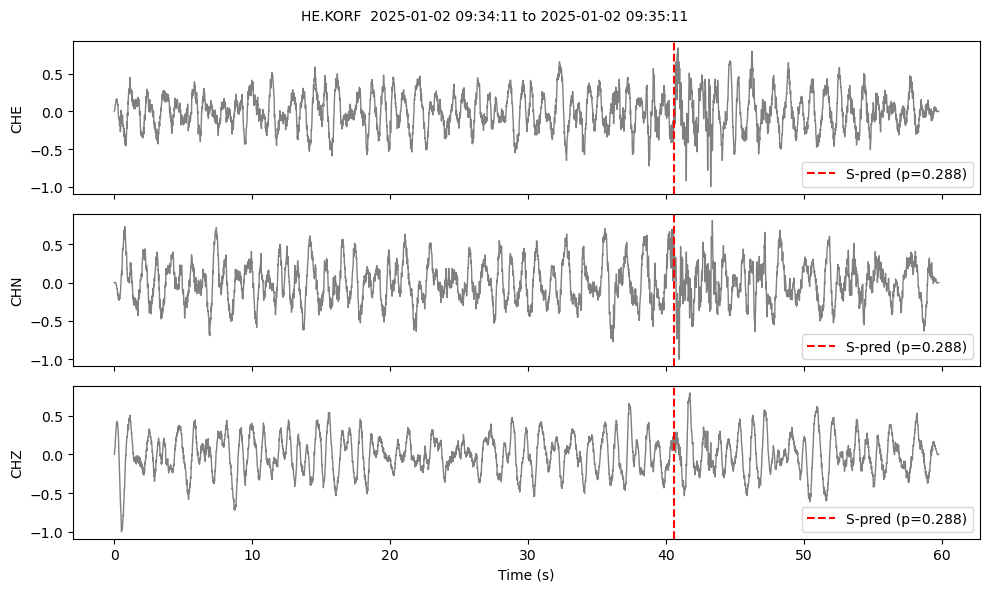

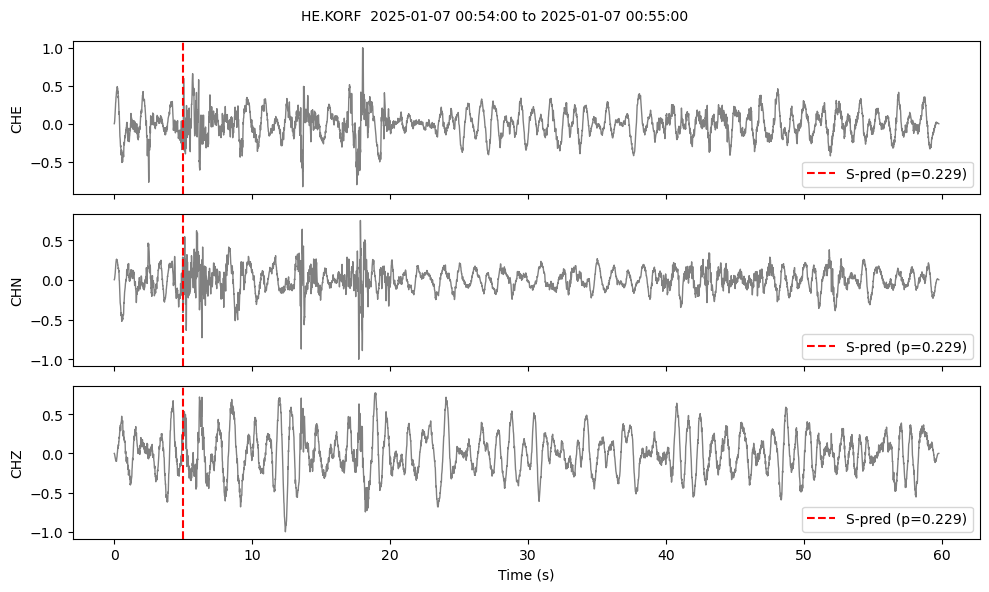

Plotted 5 false positives


In [21]:
# Example usage for plotting:
# Uncomment below and set station_name to choose which station to inspect
model = "eqt"
station_name = "HE.KORF"  # format: "NET.STA"
if model in results_noise_fp:
    plot_station_false_positives(model, station_name, results_noise_fp[model]["long"], base_path, max_plots=5)


### Combined stationwise table

In [25]:
# Combine stationwise metrics for EQT and EQCCT across earthquakes and explosions

metrics_dir = Path("../results/csv/stationwise_metrics")

# Load all metrics files
eqcct_eq = pd.read_csv(metrics_dir / "eqcct_earthquakes_th0_1_stationwise.csv")
eqcct_ex = pd.read_csv(metrics_dir / "eqcct_explosions_th0_1_stationwise.csv")
eqt_eq = pd.read_csv(metrics_dir / "eqt_earthquakes_th0_1_stationwise.csv")
eqt_ex = pd.read_csv(metrics_dir / "eqt_explosions_th0_1_stationwise.csv")

# Add model and waveform type columns
eqcct_eq["model"] = "eqcct"
eqcct_eq["waveform"] = "earthquakes"
eqcct_ex["model"] = "eqcct"
eqcct_ex["waveform"] = "explosions"
eqt_eq["model"] = "eqt"
eqt_eq["waveform"] = "earthquakes"
eqt_ex["model"] = "eqt"
eqt_ex["waveform"] = "explosions"

# Combine all into one dataframe
all_metrics = pd.concat([eqcct_eq, eqcct_ex, eqt_eq, eqt_ex], ignore_index=True)

# Pivot to get model/waveform metrics side-by-side per station
station_metrics = all_metrics.groupby(["network", "station"]).apply(
    lambda x: {
        "eqcct_eq_f1": x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]["f1_score"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqcct_ex_f1": x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]["f1_score"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]) > 0 else None,
        "eqt_eq_f1": x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]["f1_score"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqt_ex_f1": x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]["f1_score"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]) > 0 else None,
        "eqcct_eq_precision": x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]["precision"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqcct_ex_precision": x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]["precision"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]) > 0 else None,
        "eqt_eq_precision": x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]["precision"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqt_ex_precision": x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]["precision"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]) > 0 else None,
        "eqcct_eq_recall": x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]["recall"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqcct_ex_recall": x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]["recall"].values[0] if len(x[(x["model"] == "eqcct") & (x["waveform"] == "explosions")]) > 0 else None,
        "eqt_eq_recall": x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]["recall"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "earthquakes")]) > 0 else None,
        "eqt_ex_recall": x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]["recall"].values[0] if len(x[(x["model"] == "eqt") & (x["waveform"] == "explosions")]) > 0 else None,
        "eq_windows": x[(x["waveform"] == "earthquakes")]["num_rows"].values[0] if len(x[(x["waveform"] == "earthquakes")]) > 0 else None,
        "ex_windows": x[(x["waveform"] == "explosions")]["num_rows"].values[0] if len(x[(x["waveform"] == "explosions")]) > 0 else None,
    },
    include_groups=False
).apply(pd.Series).reset_index()

# Calculate average F1 for EQT across both waveform types
station_metrics["eqt_avg_f1"] = station_metrics[["eqt_eq_f1", "eqt_ex_f1"]].mean(axis=1)

# Save combined metrics to CSV
output_path = metrics_dir / "combined_stationwise_metrics.csv"
station_metrics.to_csv(output_path, index=False)
print(f"✓ Saved combined metrics to {output_path}")


✓ Saved combined metrics to ../results/csv/stationwise_metrics/combined_stationwise_metrics.csv


In [26]:


station_metrics_sorted = station_metrics.sort_values("eqt_ex_recall")
display(station_metrics_sorted)

,network,station,eqcct_eq_f1,eqcct_ex_f1,eqt_eq_f1,eqt_ex_f1,eqcct_eq_precision,eqcct_ex_precision,eqt_eq_precision,eqt_ex_precision,eqcct_eq_recall,eqcct_ex_recall,eqt_eq_recall,eqt_ex_recall,eq_windows,ex_windows,eqt_avg_f1
37,HE,OBF8,0.710744,0.218487,0.625000,0.136752,0.895833,0.928571,0.727273,0.666667,0.589041,0.123810,0.547945,0.076190,28.0,12.0,0.380876
51,HE,VUOS,0.745763,0.372603,0.666667,0.259587,0.785714,0.894737,0.850000,0.880000,0.709677,0.235294,0.548387,0.152249,18.0,42.0,0.463127
9,HE,ALAJF,0.785714,0.327869,0.869565,0.275862,0.696203,0.909091,0.925926,1.000000,0.901639,0.200000,0.819672,0.160000,41.0,13.0,0.572714
34,HE,NUR,0.785714,0.319328,0.791045,0.271386,0.887097,0.791667,0.946429,0.851852,0.705128,0.200000,0.679487,0.161404,37.0,44.0,0.531216
12,HE,FIA1,0.782258,0.336207,0.686695,0.279476,0.898148,1.000000,0.860215,0.888889,0.692857,0.202073,0.571429,0.165803,63.0,28.0,0.483086
6,FN,RANF,0.847953,0.347418,0.841463,0.282178,0.884146,0.870588,0.920000,0.904762,0.814607,0.217009,0.775281,0.167155,94.0,56.0,0.561821
5,FN,RAJF,0.581560,0.293532,0.661417,0.282116,0.650794,0.819444,0.857143,0.835821,0.525641,0.178788,0.538462,0.169697,45.0,47.0,0.471767
13,HE,HEF,0.834320,0.337748,0.862275,0.283737,0.870370,0.772727,0.911392,0.773585,0.801136,0.216102,0.818182,0.173729,92.0,42.0,0.573006
3,FN,OLKF,0.881818,0.363636,0.889952,0.289157,0.898148,0.928571,0.958763,0.857143,0.866071,0.226087,0.830357,0.173913,59.0,51.0,0.589554
26,HE,KU6,0.892473,0.394089,0.939891,0.295515,0.912088,0.888889,0.977273,0.888889,0.873684,0.253165,0.905263,0.177215,49.0,54.0,0.617703
